In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

In [2]:
import os

for root, dirs, files in os.walk("."):
    audio_files = [f for f in files if f.lower().endswith((".wav", ".mp3", ".ogg", ".flac"))]
    if audio_files:
        print(root)
        print("Number of audio files:", len(audio_files))
        print("Examples:", audio_files[:5])
        print()

.\asbfly
Number of audio files: 10
Examples: ['XC134896 (1).ogg', 'XC164848.ogg', 'XC175797.ogg', 'XC207738.ogg', 'XC209218.ogg']

.\brnhao
Number of audio files: 10
Examples: ['XC124208.ogg', 'XC124210.ogg', 'XC125355.ogg', 'XC150289.ogg', 'XC158670.ogg']



In [3]:
def get_spectral_centroid(file_path):
    y, sr = librosa.load(file_path, sr=None)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    return np.mean(centroid)


results = []

for species in ["asbfly", "brnhao"]:
    folder = f"./{species}"
    
    for file in os.listdir(folder):
        if file.lower().endswith(".ogg"):
            path = os.path.join(folder, file)
            centroid = get_spectral_centroid(path)
            
            results.append({
                "file": file,
                "species": species,
                "spectral_centroid": centroid
            })

df = pd.DataFrame(results)

df

,file,species,spectral_centroid
0,XC134896 (1).ogg,asbfly,7734.734586
1,XC164848.ogg,asbfly,4312.599652
2,XC175797.ogg,asbfly,3712.605801
3,XC207738.ogg,asbfly,4221.187342
4,XC209218.ogg,asbfly,2315.934638
5,XC209219.ogg,asbfly,2607.607283
6,XC267679.ogg,asbfly,3391.367813
7,XC267680.ogg,asbfly,4768.305823
8,XC267681.ogg,asbfly,4744.298588
9,XC267682.ogg,asbfly,5594.218651


In [4]:
#Frequency alone dont seperate the two birds because 
#Asbyfly Range: 2316–7735 Hz, mostly 3-5hz
#whereas brnhao range: 1711–6728 Hz, but many are also high, so just frequency is not the distinct feature

<Figure size 800x500 with 0 Axes>

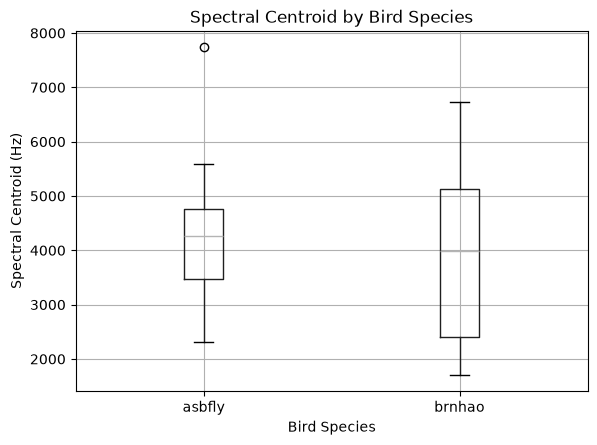

In [5]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="spectral_centroid",
    by="species"
)

plt.title("Spectral Centroid by Bird Species")
plt.suptitle("")
plt.xlabel("Bird Species")
plt.ylabel("Spectral Centroid (Hz)")
plt.show()

In [6]:
#spectral centroid distributions overlap quite a lot.

In [7]:
def get_spectral_bandwidth(file_path):
    y, sr = librosa.load(file_path, sr=None)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    return np.mean(bandwidth)


df["spectral_bandwidth"] = df["file"].apply(
    lambda file: get_spectral_bandwidth(
        os.path.join(".", df.loc[df["file"] == file, "species"].iloc[0], file)
    )
)

df

,file,species,spectral_centroid,spectral_bandwidth
0,XC134896 (1).ogg,asbfly,7734.734586,3064.779846
1,XC164848.ogg,asbfly,4312.599652,3994.579064
2,XC175797.ogg,asbfly,3712.605801,2523.320918
3,XC207738.ogg,asbfly,4221.187342,4142.454873
4,XC209218.ogg,asbfly,2315.934638,3376.695131
5,XC209219.ogg,asbfly,2607.607283,3672.954875
6,XC267679.ogg,asbfly,3391.367813,3828.460690
7,XC267680.ogg,asbfly,4768.305823,3993.206285
8,XC267681.ogg,asbfly,4744.298588,4019.026878
9,XC267682.ogg,asbfly,5594.218651,4193.328228


In [8]:
#Spectral Bandwidth: This measures roughly how spread out the frequency energy is around the spectral centroid.

<Figure size 800x500 with 0 Axes>

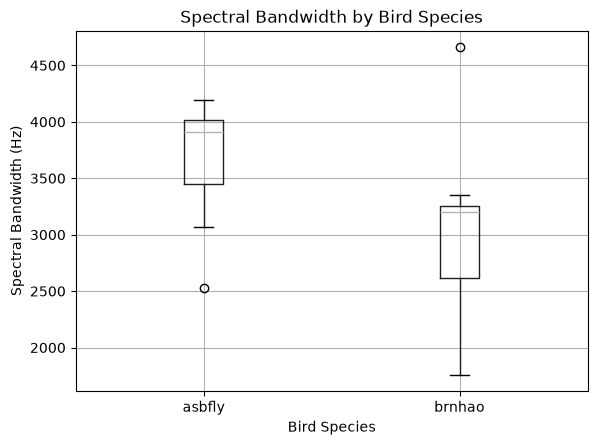

In [9]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="spectral_bandwidth",
    by="species"
)

plt.title("Spectral Bandwidth by Bird Species")
plt.suptitle("")
plt.xlabel("Bird Species")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.show()

In [10]:
#Asbfly → energy spread across a wider frequency range
#Brnhao → energy more concentrated

In [11]:
def get_zcr(file_path):
    y, sr = librosa.load(file_path, sr=None)
    zcr = librosa.feature.zero_crossing_rate(y)
    return np.mean(zcr)


df["zcr"] = df.apply(
    lambda row: get_zcr(
        os.path.join(".", row["species"], row["file"])
    ),
    axis=1
)

df

,file,species,spectral_centroid,spectral_bandwidth,zcr
0,XC134896 (1).ogg,asbfly,7734.734586,3064.779846,0.448772
1,XC164848.ogg,asbfly,4312.599652,3994.579064,0.202128
2,XC175797.ogg,asbfly,3712.605801,2523.320918,0.211443
3,XC207738.ogg,asbfly,4221.187342,4142.454873,0.160501
4,XC209218.ogg,asbfly,2315.934638,3376.695131,0.057760
5,XC209219.ogg,asbfly,2607.607283,3672.954875,0.069817
6,XC267679.ogg,asbfly,3391.367813,3828.460690,0.089895
7,XC267680.ogg,asbfly,4768.305823,3993.206285,0.205726
8,XC267681.ogg,asbfly,4744.298588,4019.026878,0.204242
9,XC267682.ogg,asbfly,5594.218651,4193.328228,0.251566


<Figure size 800x500 with 0 Axes>

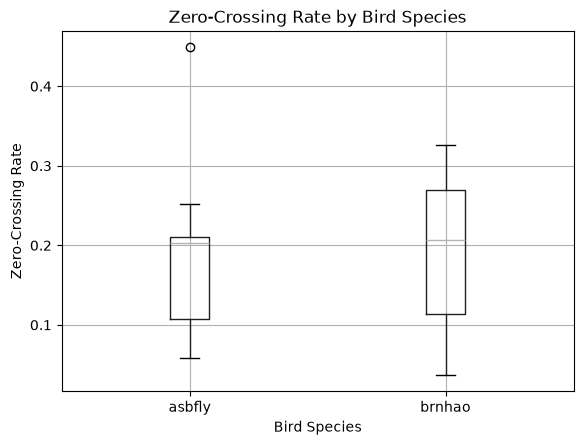

In [12]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="zcr",
    by="species"
)

plt.title("Zero-Crossing Rate by Bird Species")
plt.suptitle("")
plt.xlabel("Bird Species")
plt.ylabel("Zero-Crossing Rate")
plt.show()

In [13]:
def get_rms(file_path):
    y, sr = librosa.load(file_path, sr=None)
    rms = librosa.feature.rms(y=y)
    return np.mean(rms)


df["rms"] = df.apply(
    lambda row: get_rms(
        os.path.join(".", row["species"], row["file"])
    ),
    axis=1
)

df

,file,species,spectral_centroid,spectral_bandwidth,zcr,rms
0,XC134896 (1).ogg,asbfly,7734.734586,3064.779846,0.448772,0.003711
1,XC164848.ogg,asbfly,4312.599652,3994.579064,0.202128,0.002667
2,XC175797.ogg,asbfly,3712.605801,2523.320918,0.211443,0.041398
3,XC207738.ogg,asbfly,4221.187342,4142.454873,0.160501,0.007737
4,XC209218.ogg,asbfly,2315.934638,3376.695131,0.057760,0.060153
5,XC209219.ogg,asbfly,2607.607283,3672.954875,0.069817,0.061236
6,XC267679.ogg,asbfly,3391.367813,3828.460690,0.089895,0.013856
7,XC267680.ogg,asbfly,4768.305823,3993.206285,0.205726,0.009528
8,XC267681.ogg,asbfly,4744.298588,4019.026878,0.204242,0.009245
9,XC267682.ogg,asbfly,5594.218651,4193.328228,0.251566,0.017924


<Figure size 800x500 with 0 Axes>

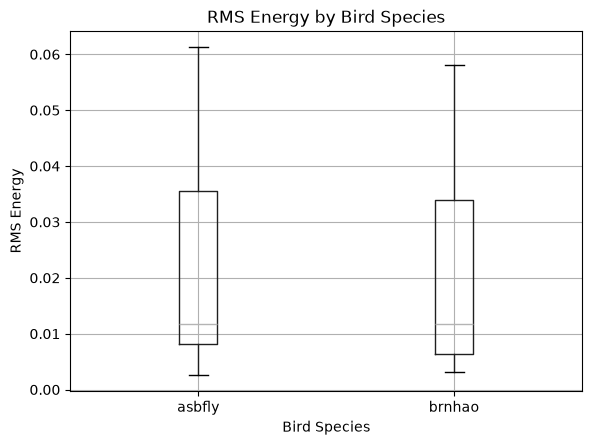

In [14]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="rms",
    by="species"
)

plt.title("RMS Energy by Bird Species")
plt.suptitle("")
plt.xlabel("Bird Species")
plt.ylabel("RMS Energy")
plt.show()

In [15]:
summary = df.groupby("species")[
    ["spectral_centroid", "spectral_bandwidth", "zcr", "rms"]
].agg(["mean", "median", "std"])

summary

spectral_centroid                           spectral_bandwidth  \
                     mean       median          std               mean   
species                                                                  
asbfly        4340.286018  4266.893497  1558.154485        3680.880679   
brnhao        3923.127852  3987.243281  1772.948447        3049.087760   

                                       zcr                           rms  \
              median         std      mean    median       std      mean   
species                                                                    
asbfly   3910.833488  539.531320  0.190185  0.203185  0.112858  0.022745   
brnhao   3204.536462  753.788861  0.192212  0.206820  0.107438  0.020991   

                             
           median       std  
species                      
asbfly   0.011692  0.022800  
brnhao   0.011686  0.019541

In [16]:
from scipy.stats import ttest_ind

features = [
    "spectral_centroid",
    "spectral_bandwidth",
    "zcr",
    "rms"
]

for feature in features:
    asbfly = df[df["species"] == "asbfly"][feature]
    brnhao = df[df["species"] == "brnhao"][feature]
    
    t_stat, p_value = ttest_ind(
        asbfly,
        brnhao,
        equal_var=False
    )
    
    print(f"{feature}")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.4f}")
    print()

spectral_centroid
t-statistic: 0.559
p-value: 0.5832

spectral_bandwidth
t-statistic: 2.155
p-value: 0.0464

zcr
t-statistic: -0.041
p-value: 0.9676

rms
t-statistic: 0.185
p-value: 0.8556



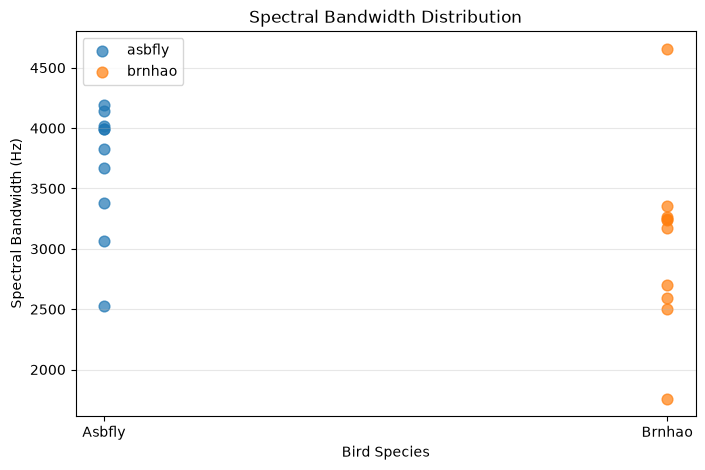

In [17]:
plt.figure(figsize=(8, 5))

for species, x in [("asbfly", 0), ("brnhao", 1)]:
    values = df[df["species"] == species]["spectral_bandwidth"]
    
    plt.scatter(
        [x] * len(values),
        values,
        s=60,
        alpha=0.7,
        label=species
    )

plt.xticks([0, 1], ["Asbfly", "Brnhao"])
plt.ylabel("Spectral Bandwidth (Hz)")
plt.xlabel("Bird Species")
plt.title("Spectral Bandwidth Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [18]:
thresholds = np.sort(df["spectral_bandwidth"].unique())

best_threshold = None
best_accuracy = 0

for threshold in thresholds:
    predictions = np.where(
        df["spectral_bandwidth"] > threshold,
        "asbfly",
        "brnhao"
    )
    
    accuracy = np.mean(predictions == df["species"])
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Accuracy:", best_accuracy)
print("Accuracy (%):", best_accuracy * 100)

Best threshold: 3355.8009243812758
Accuracy: 0.85
Accuracy (%): 85.0


In [19]:
df["prediction"] = np.where(
    df["spectral_bandwidth"] > best_threshold,
    "asbfly",
    "brnhao"
)

df["correct"] = df["prediction"] == df["species"]

df[[
    "file",
    "species",
    "spectral_bandwidth",
    "prediction",
    "correct"
]]

,file,species,spectral_bandwidth,prediction,correct
0,XC134896 (1).ogg,asbfly,3064.779846,brnhao,False
1,XC164848.ogg,asbfly,3994.579064,asbfly,True
2,XC175797.ogg,asbfly,2523.320918,brnhao,False
3,XC207738.ogg,asbfly,4142.454873,asbfly,True
4,XC209218.ogg,asbfly,3376.695131,asbfly,True
5,XC209219.ogg,asbfly,3672.954875,asbfly,True
6,XC267679.ogg,asbfly,3828.460690,asbfly,True
7,XC267680.ogg,asbfly,3993.206285,asbfly,True
8,XC267681.ogg,asbfly,4019.026878,asbfly,True
9,XC267682.ogg,asbfly,4193.328228,asbfly,True


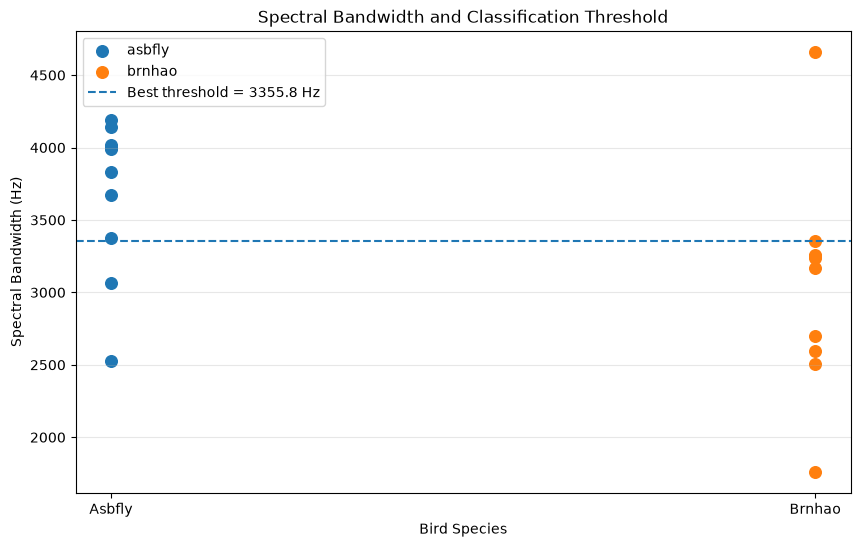

In [20]:
plt.figure(figsize=(10, 6))

for species, x in [("asbfly", 0), ("brnhao", 1)]:
    values = df[df["species"] == species]["spectral_bandwidth"]
    
    plt.scatter(
        [x] * len(values),
        values,
        s=70,
        label=species
    )

plt.axhline(
    y=best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.1f} Hz"
)

plt.xticks([0, 1], ["Asbfly", "Brnhao"])
plt.ylabel("Spectral Bandwidth (Hz)")
plt.xlabel("Bird Species")
plt.title("Spectral Bandwidth and Classification Threshold")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

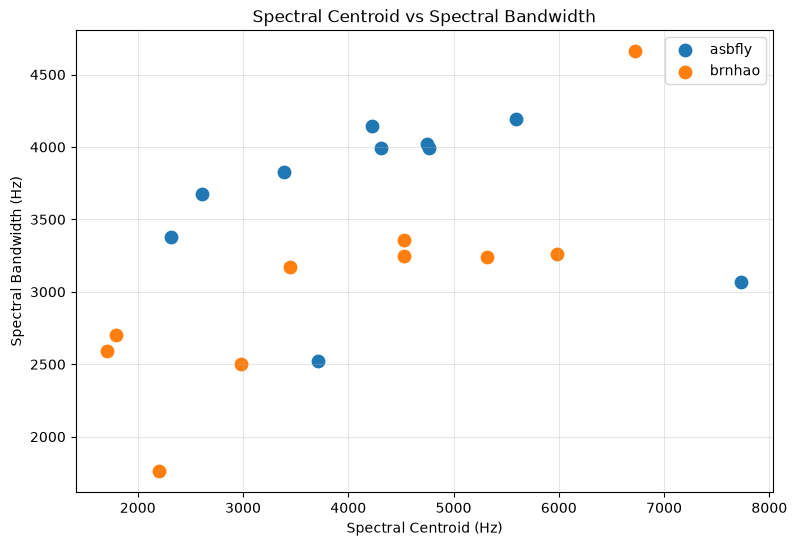

In [21]:
plt.figure(figsize=(9, 6))

for species in ["asbfly", "brnhao"]:
    subset = df[df["species"] == species]
    
    plt.scatter(
        subset["spectral_centroid"],
        subset["spectral_bandwidth"],
        s=80,
        label=species
    )

plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.title("Spectral Centroid vs Spectral Bandwidth")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

X = df[["spectral_centroid", "spectral_bandwidth"]]
y = df["species"]

lda = LinearDiscriminantAnalysis()
loo = LeaveOneOut()

predictions = []
actual = []

for train_index, test_index in loo.split(X):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]
    
    lda.fit(X_train, y_train)
    prediction = lda.predict(X_test)
    
    predictions.append(prediction[0])
    actual.append(y_test.iloc[0])

accuracy = accuracy_score(actual, predictions)

print("LDA Accuracy:", accuracy)
print("LDA Accuracy (%):", accuracy * 100)

LDA Accuracy: 0.8
LDA Accuracy (%): 80.0


In [23]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

loo = LeaveOneOut()

predictions = []
actual = []

for train_index, test_index in loo.split(df):
    
    train = df.iloc[train_index]
    test = df.iloc[test_index]
    
    # Find the best bandwidth threshold using ONLY training data
    thresholds = np.sort(train["spectral_bandwidth"].unique())
    
    best_threshold_train = None
    best_accuracy_train = 0
    
    for threshold in thresholds:
        train_predictions = np.where(
            train["spectral_bandwidth"] > threshold,
            "asbfly",
            "brnhao"
        )
        
        train_accuracy = np.mean(
            train_predictions == train["species"]
        )
        
        if train_accuracy > best_accuracy_train:
            best_accuracy_train = train_accuracy
            best_threshold_train = threshold
    
    # Use that threshold on the unseen test recording
    test_prediction = (
        "asbfly"
        if test["spectral_bandwidth"].iloc[0] > best_threshold_train
        else "brnhao"
    )
    
    predictions.append(test_prediction)
    actual.append(test["species"].iloc[0])

accuracy = accuracy_score(actual, predictions)

print("Bandwidth Threshold LOOCV Accuracy:", accuracy)
print("Bandwidth Threshold LOOCV Accuracy (%):", accuracy * 100)

Bandwidth Threshold LOOCV Accuracy: 0.8
Bandwidth Threshold LOOCV Accuracy (%): 80.0


In [24]:
from scipy.stats import ttest_ind

features = [
    "spectral_centroid",
    "spectral_bandwidth",
    "zcr",
    "rms"
]

effect_results = []

for feature in features:
    a = df[df["species"] == "asbfly"][feature]
    b = df[df["species"] == "brnhao"][feature]
    
    n1 = len(a)
    n2 = len(b)
    
    pooled_std = np.sqrt(
        ((n1 - 1) * a.var() + (n2 - 1) * b.var())
        / (n1 + n2 - 2)
    )
    
    cohens_d = (a.mean() - b.mean()) / pooled_std
    
    effect_results.append({
        "feature": feature,
        "cohens_d": cohens_d,
        "absolute_effect": abs(cohens_d)
    })

effect_df = pd.DataFrame(effect_results)

effect_df.sort_values(
    "absolute_effect",
    ascending=False
)

,feature,cohens_d,absolute_effect
1,spectral_bandwidth,0.963872,0.963872
0,spectral_centroid,0.249943,0.249943
3,rms,0.082614,0.082614
2,zcr,-0.018400,0.018400
